In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

#untuk dapat melihat seluruh kolom dan baris
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Read TransJakarta Transaction Data

source: https://www.kaggle.com/datasets/dikisahkan/transjakarta-transportation-transaction

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dfTransjakarta.csv")

In [ ]:
#check dimensi data
df.shape
#len(df)

(37900, 22)

In [ ]:
#tampilkan top 5 data
df.head()

,transID,payCardID,payCardBank,payCardName,payCardSex,payCardBirthDate,corridorID,corridorName,direction,tapInStops,tapInStopsName,tapInStopsLat,tapInStopsLon,stopStartSeq,tapInTime,tapOutStops,tapOutStopsName,tapOutStopsLat,tapOutStopsLon,stopEndSeq,tapOutTime,payAmount
0,EIIW227B8L34VB,180062659848800,emoney,Bajragin Usada,M,2008,5,Matraman Baru - Ancol,1.0,P00142,Pal Putih,-6.184631,106.84402,7,2023-04-03 05:21:44,P00253,Tegalan,-6.203101,106.85715,12.0,2023-04-03 06:00:53,3500.0
1,LGXO740D2N47GZ,4885331907664776,dki,Gandi Widodo,F,1997,6C,Stasiun Tebet - Karet via Patra Kuningan,0.0,B01963P,Kemenkes 2,-6.228700,106.83302,13,2023-04-03 05:42:44,B03307P,Sampoerna Strategic,-6.217152,106.81892,21.0,2023-04-03 06:40:01,3500.0
2,DJWR385V2U57TO,4996225095064169,dki,Emong Wastuti,F,1992,R1A,Pantai Maju - Kota,0.0,B00499P,Gg. Kunir II,-6.133132,106.81435,38,2023-04-03 05:59:06,B04962P,Simpang Kunir Kemukus,-6.133731,106.81475,39.0,2023-04-03 06:50:55,3500.0
3,JTUZ800U7C86EH,639099174703,flazz,Surya Wacana,F,1978,11D,Pulo Gebang - Pulo Gadung 2 via PIK,0.0,B05587P,Taman Elok 1,-6.195743,106.93526,23,2023-04-03 05:44:51,B03090P,Raya Penggilingan,-6.183068,106.93194,29.0,2023-04-03 06:28:16,3500.0
4,VMLO535V7F95NJ,570928206772,flazz,Embuh Mardhiyah,M,1982,12,Tanjung Priok - Pluit,0.0,P00239,Sunter Boulevard Barat,-6.149650,106.88900,5,2023-04-03 06:17:35,P00098,Kali Besar Barat,-6.135355,106.81143,15.0,2023-04-03 06:57:03,3500.0


In [ ]:
#buat beberapa kolom tambahan
df['age'] = 2024-df['payCardBirthDate']
df['numStop'] = df['stopEndSeq']-df['stopStartSeq']
df['tapInTime'] = pd.to_datetime(df['tapInTime'])
df['tapOutTime'] = pd.to_datetime(df['tapOutTime'])
df['durationMinutes'] = (df['tapOutTime'] - df['tapInTime']).dt.total_seconds() / 60
df['tapInDate'] = df['tapInTime'].dt.date
df.sample(5)

,transID,payCardID,payCardBank,payCardName,payCardSex,payCardBirthDate,corridorID,corridorName,direction,tapInStops,tapInStopsName,tapInStopsLat,tapInStopsLon,stopStartSeq,tapInTime,tapOutStops,tapOutStopsName,tapOutStopsLat,tapOutStopsLon,stopEndSeq,tapOutTime,payAmount,age,numStop,durationMinutes,tapInDate
20168,GNFK305Y4H69AD,38919000659661,bni,Anggabaya Suartini,F,1994,11Q,Kampung Melayu - Pulo Gebang via BKT,1.0,P00169,Penggilingan,-6.214132,106.93961,25,2023-04-13 06:05:14,P00270,Walikota Jakarta Timur,-6.212540,106.94537,26.0,2023-04-13 07:48:55,3500.0,30,1.0,103.683333,2023-04-13
3571,HQDV372O1K99IH,3563151380900971,dki,Indah Habibi,M,1979,8,Lebak Bulus - Pasar Baru via Tomang,0.0,P00282,Grogol 2 Arah Selatan,-6.167435,106.78856,18,2023-04-10 16:03:32,P00147,Pasar Baru,-6.166129,106.83483,25.0,2023-04-10 17:13:47,3500.0,45,7.0,70.250000,2023-04-10
3840,BPVT832Y9A60CL,342370004909630,emoney,"Kartika Habibi, S.Psi",M,1975,6D,Stasiun Tebet - Karet via Underpass,0.0,B04505P,Sbr. Standard Chartered,-6.217407,106.81934,13,2023-04-11 05:36:21,B03396P,Kota Kasablanka,-6.224688,106.84246,20.0,2023-04-11 06:07:20,3500.0,49,7.0,30.983333,2023-04-11
13079,LUFG136D1Z41HZ,2720067582504076,dki,Nova Nugroho,M,1999,NaN,NaN,1.0,P00218,Senayan JCC Arah Timur,-6.214145,106.80900,15,2023-04-04 08:31:05,P00071,Gelora Bung Karno,-6.224217,106.80580,16.0,2023-04-04 09:15:50,3500.0,25,1.0,44.750000,2023-04-04
7453,AHCJ656R1R83XK,3531178674835422,dki,"R. Sadina Sinaga, S.Psi",F,1992,JAK.16,Cililitan - Condet,0.0,B06791P,SDN 11 Batu Ampar,-6.284068,106.85835,16,2023-04-19 05:07:01,B02495P,Munggang 1,-6.276272,106.85299,25.0,2023-04-19 05:40:34,0.0,32,9.0,33.550000,2023-04-19


In [ ]:
#membuat data summary daily
daily_df = df.groupby('tapInDate').agg(
    numTrans=('tapInTime', 'count'),
    uniqueUsers=('payCardID', 'nunique'),
    totalAmount=('payAmount', 'sum'),
    avgAmount=('payAmount', 'mean'),
    medianAmount=('payAmount', 'median'),
    avgDuration=('durationMinutes', 'mean'),
    medianDuration=('durationMinutes', 'median'),
    avgStop=('numStop', 'mean'),
    medianStop=('numStop', 'median'),
    avgAge=('age', 'mean'),
    medianAge=('age', 'median'),
).reset_index()
daily_df.head()

,tapInDate,numTrans,uniqueUsers,totalAmount,avgAmount,medianAmount,avgDuration,medianDuration,avgStop,medianStop,avgAge,medianAge
0,2023-04-01,14,14,48000.0,3428.571429,3500.0,81.913095,84.733333,4.785714,4.0,40.857143,36.5
1,2023-04-02,8,8,21000.0,2625.000000,3500.0,93.378571,104.483333,7.142857,3.0,37.000000,38.5
2,2023-04-03,1611,811,4287500.0,2732.632250,3500.0,71.227412,71.233333,7.586718,5.0,33.956549,34.0
3,2023-04-04,1609,809,4294500.0,2740.587109,3500.0,72.451583,72.816667,7.627086,5.0,33.972654,34.0
4,2023-04-05,1609,809,4284000.0,2735.632184,3500.0,70.820928,69.866667,7.657775,5.0,33.941579,34.0


In [ ]:
card_df = df.groupby('payCardBank').agg(
    numTrans=('tapInTime', 'count'),
    uniqueUsers=('payCardID', 'nunique')
).reset_index()
card_df.head()

,payCardBank,numTrans,uniqueUsers
0,bni,2657,155
1,brizzi,3531,165
2,dki,18743,984
3,emoney,6866,372
4,flazz,3234,171


# MATPLOTLIB



## Line chart

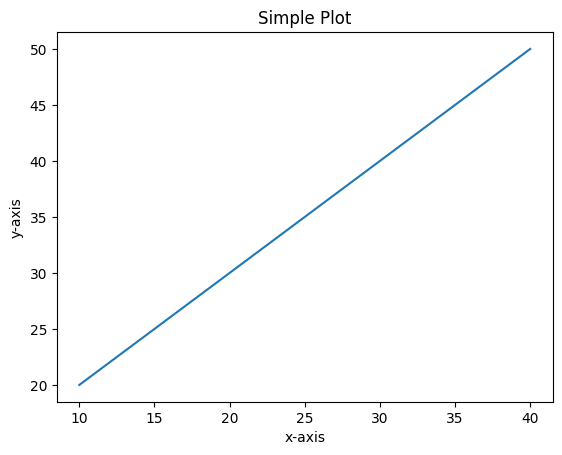

In [ ]:
# contoh data dalam array
x = [10, 20, 30, 40]
y = [20, 30, 40, 50]

# plotting data
plt.plot(x, y)

# menambahkan keterangan
plt.title("Simple Plot")
plt.ylabel("y-axis")
plt.xlabel("x-axis")

plt.show()

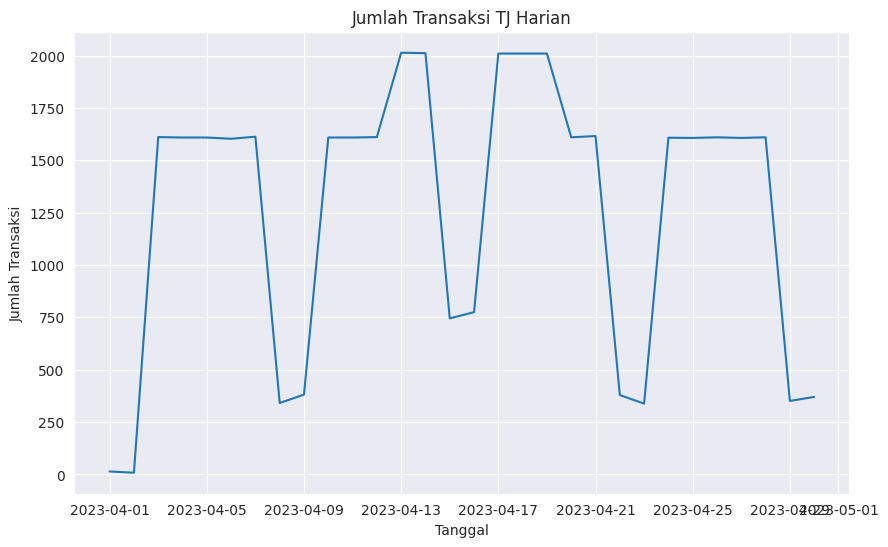

In [ ]:
#contoh dengan dataframe

# Menentukan ukuran figure
plt.figure(figsize=(10, 6))

plt.plot(daily_df['tapInDate'], daily_df['numTrans'])
# plt.plot(daily_df['tapInDate'], daily_df['numTrans'],'o')

# menambahkan keterangan
plt.title("Jumlah Transaksi TJ Harian")
plt.ylabel("Jumlah Transaksi")
plt.xlabel("Tanggal")

plt.show()

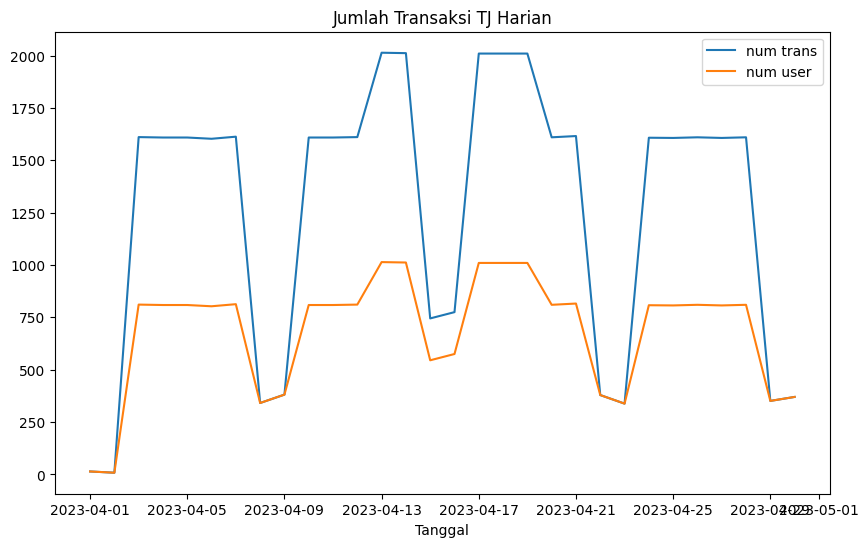

In [ ]:
#contoh multiple line

plt.figure(figsize=(10, 6))

plt.plot(daily_df['tapInDate'], daily_df['numTrans'] , label = 'num trans')
plt.plot(daily_df['tapInDate'], daily_df['uniqueUsers'] , label = 'num user')
plt.legend()

plt.title("Jumlah Transaksi TJ Harian")
plt.xlabel("Tanggal")

plt.show()

## Bar Chart

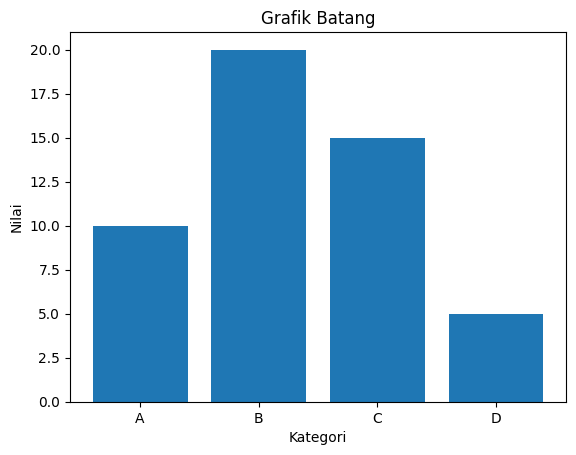

In [ ]:
# Data
kategori = ['A', 'B', 'C', 'D']
nilai = [10, 20, 15, 5]

# Membuat grafik batang
plt.bar(kategori, nilai)

# Menambahkan judul dan label
plt.title('Grafik Batang')
plt.xlabel('Kategori')
plt.ylabel('Nilai')

# Menampilkan grafik
plt.show()

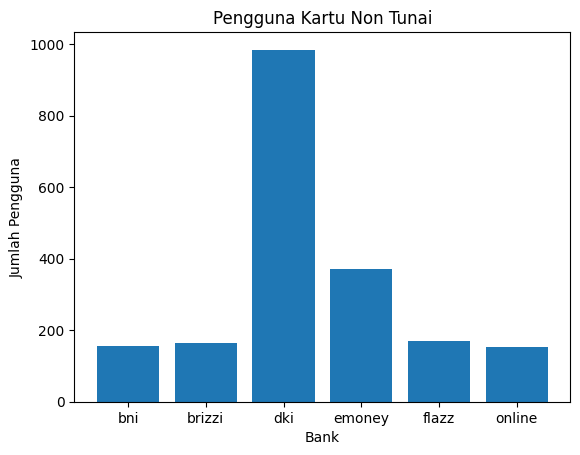

In [ ]:
plt.bar(card_df['payCardBank'], card_df['uniqueUsers'])

# Menambahkan judul dan label
plt.title('Pengguna Kartu Non Tunai')
plt.xlabel('Bank')
plt.ylabel('Jumlah Pengguna')

# Menampilkan grafik
plt.show()

## Scatter Plot

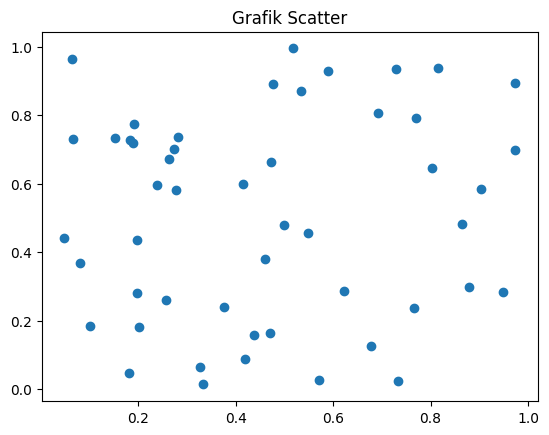

In [ ]:
# Data
x = np.random.rand(50)
y = np.random.rand(50)

# Membuat grafik scatter
plt.scatter(x, y)

# Menambahkan judul
plt.title('Grafik Scatter')

# Menampilkan grafik
plt.show()

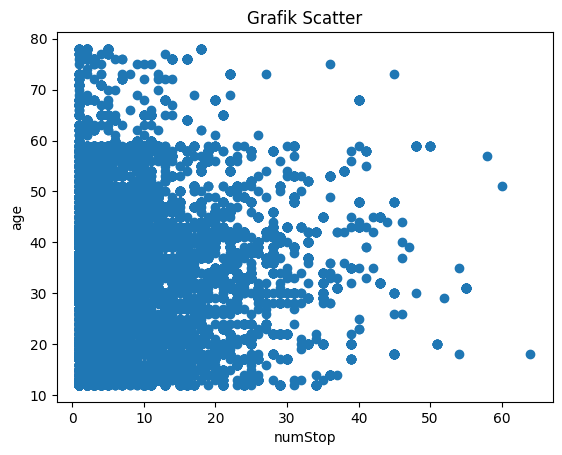

In [ ]:
plt.scatter(df['numStop'], df["age"])


# Menambahkan judul
plt.title('Grafik Scatter')
plt.xlabel('numStop')
plt.ylabel('age')

# Menampilkan grafik
plt.show()

## Histogram Chart

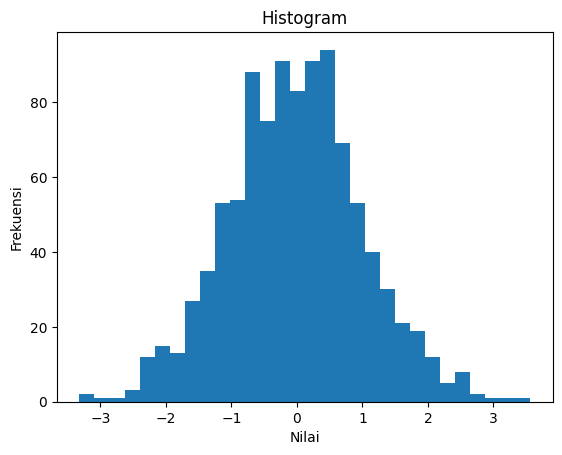

In [ ]:
# Data
data = np.random.randn(1000)

# Membuat histogram
plt.hist(data, bins=30)

# Menambahkan judul dan label
plt.title('Histogram')
plt.xlabel('Nilai')
plt.ylabel('Frekuensi')

# Menampilkan grafik
plt.show()


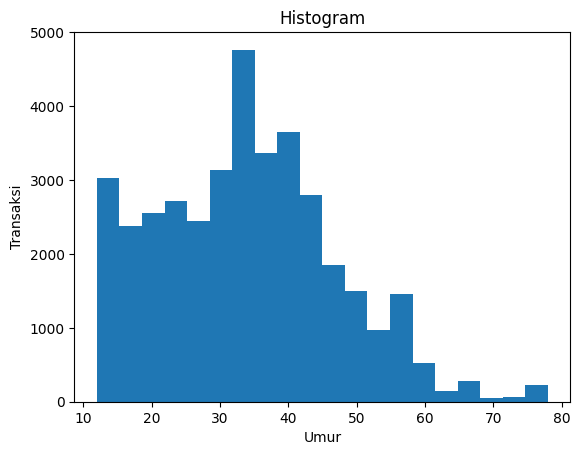

In [ ]:
# Membuat histogram
plt.hist(df['age'], bins=20)

# Menambahkan judul dan label
plt.title('Histogram')
plt.xlabel('Umur')
plt.ylabel('Transaksi')

# Menampilkan grafik
plt.show()

# SEABORN

In [ ]:
sns.set_style("darkgrid") # Contoh tema: darkgrid, whitegrid, dark, white, dan ticks

## Line Chart

In [ ]:
daily_df.sample(1)

,tapInDate,numTrans,uniqueUsers,totalAmount,avgAmount,medianAmount,avgDuration,medianDuration,avgStop,medianStop,avgAge,medianAge
8,2023-04-09,381,381,970000.0,2586.666667,3500.0,66.538707,66.158333,7.827869,5.0,33.167979,32.0


In [ ]:
df.sample(1)

,transID,payCardID,payCardBank,payCardName,payCardSex,payCardBirthDate,corridorID,corridorName,direction,tapInStops,tapInStopsName,tapInStopsLat,tapInStopsLon,stopStartSeq,tapInTime,tapOutStops,tapOutStopsName,tapOutStopsLat,tapOutStopsLon,stopEndSeq,tapOutTime,payAmount,age,numStop,durationMinutes,tapInDate
12098,TEYU581N8Y93IQ,2276099634138221,dki,Ir. Farhunnisa Aryani,F,1994,T11,Poris Plawad - Bundaran Senayan,1.0,B03226P,Rukan Teuku Umar,-6.195499,106.62391,17,2023-04-03 06:07:45,B05720P,Term. Poris Plawad,-6.172859,106.66501,23.0,2023-04-03 06:37:33,3500.0,30,6.0,29.8,2023-04-03


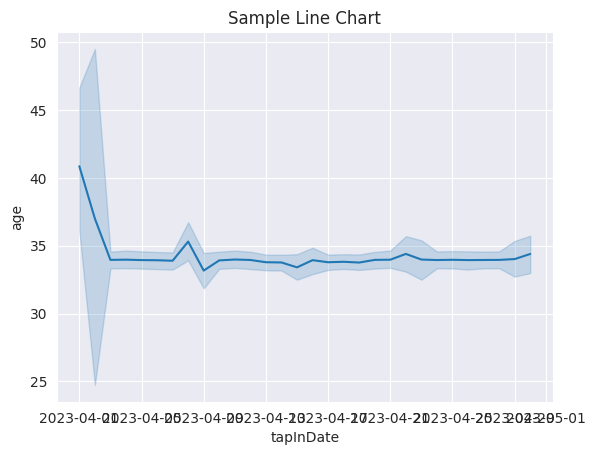

In [ ]:

# sns.lineplot(x="tapInDate", y="avgAge", data=daily_df)
sns.lineplot(x="tapInDate", y="age", data=df)
# sns.lineplot(x="tapInDate", y="age", hue="direction", style="payCardSex", markers=True, dashes=False, data=df)

# add labels and title
plt.xlabel("tapInDate")
plt.ylabel("age")
plt.title("Sample Line Chart")

# display the plot

plt.show()

## Bar Chart

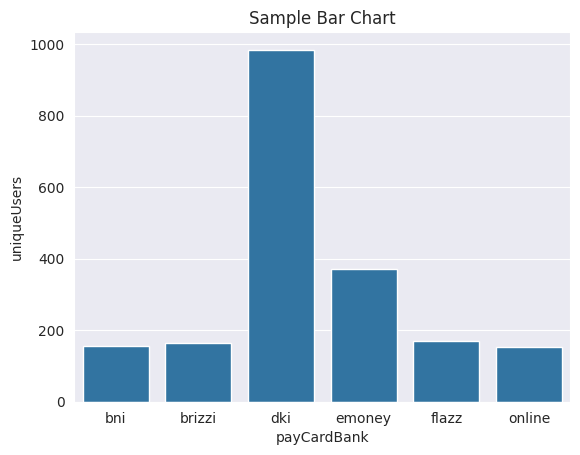

In [ ]:
sns.barplot(x="payCardBank", y="uniqueUsers", data=card_df)

#automatically calculate average
# sns.barplot(x="payCardBank", y="age", hue="payCardSex", ci=None, palette="pastel", data=df)


# add labels and title
plt.title("Sample Bar Chart")

# display the plot
plt.show()

## Scatter plot

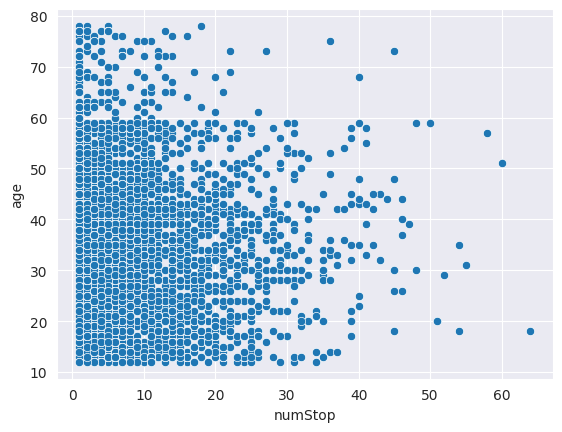

In [ ]:
sns.scatterplot(x="numStop", y="age", data=df)
# sns.scatterplot(x="numStop", y="age", hue="payCardSex",  data=df)
plt.show()

## Histogram Chart

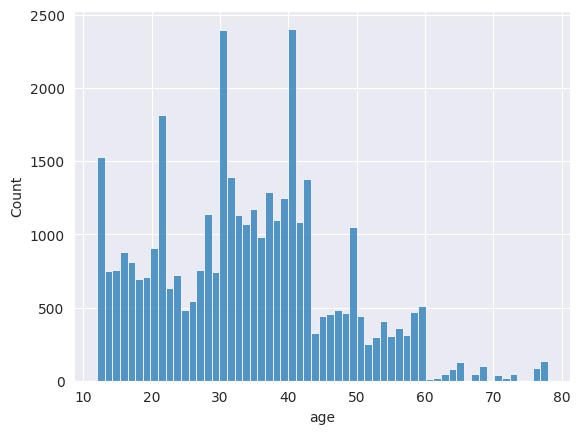

In [ ]:
sns.histplot(x="age", data=df)

# sns.histplot(x="age", data=df, bins=20, kde=True, color="green")
#Plot KDE (Kernel Density Estimation) adalah sebuah grafik yang menunjukkan seberapa padat atau sering data muncul di berbagai titik.

plt.show()

## Heatmap

<ipython-input-25-fae5d55b8570>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = daily_df.corr()


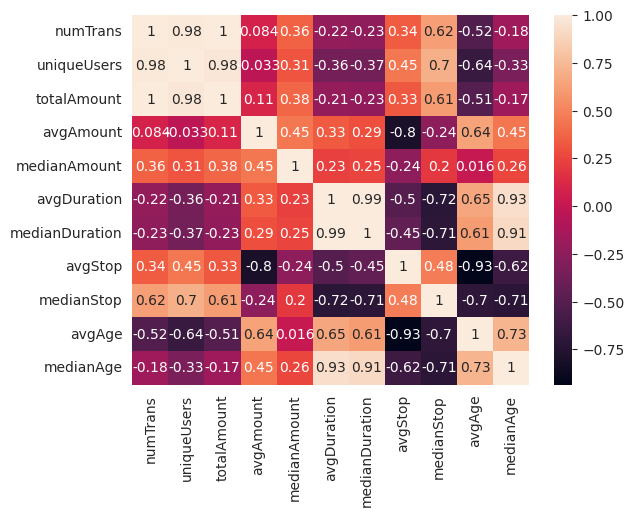

In [ ]:
# Menghitung korelasi
corr = daily_df.corr()

# Membuat heatmap dari korelasi
sns.heatmap(corr, annot=True) # annot=True menampilkan nilai korelasi pada heatmap

# Menampilkan plot
plt.show()

#PANDAS PLOT

## Line Chart

<Axes: xlabel='tapInDate'>

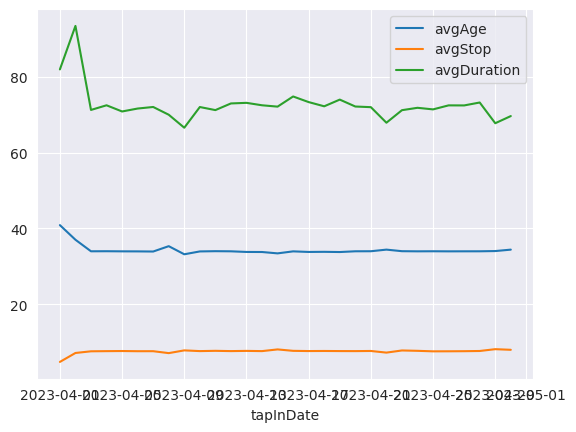

In [ ]:
# Membuat line plot
daily_df.set_index('tapInDate',inplace=True)
daily_df[['avgAge','avgStop','avgDuration']].plot()

## Bar Chart

<Axes: >

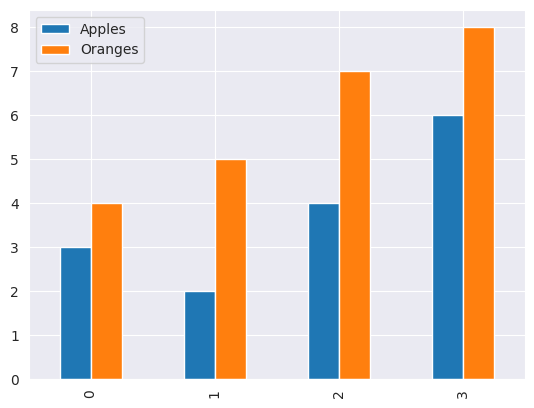

In [ ]:
# Data contoh
data = {'Apples': [3, 2, 4, 6], 'Oranges': [4, 5, 7, 8]}
df = pd.DataFrame(data)

# Membuat bar chart
df.plot.bar()

## Scatter plot

<Axes: xlabel='X', ylabel='Y'>

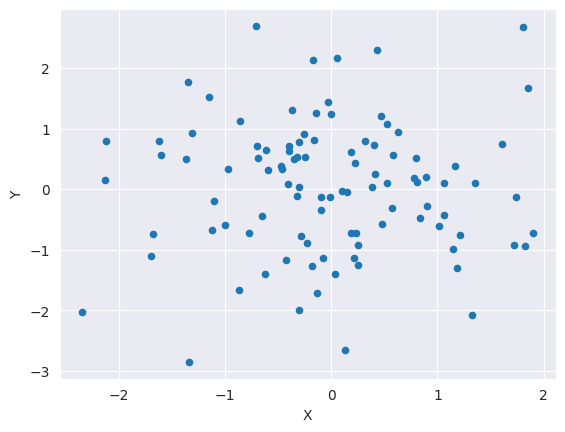

In [ ]:
# Data contoh
df = pd.DataFrame({
    'X': np.random.randn(100),
    'Y': np.random.randn(100)
})

# Membuat scatter plot
df.plot.scatter(x='X', y='Y')

## Histogram Chart

<Axes: ylabel='Frequency'>

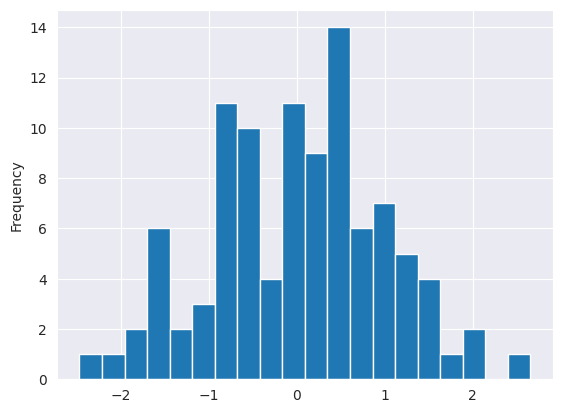

In [ ]:
# Data contoh
df = pd.DataFrame({
    'Data': np.random.randn(100)
})

# Membuat histogram
df['Data'].plot.hist(bins=20)